# Preprocessing and EDA

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

df_raw = pd.read_csv('../data/combined.csv')

## Step 1: Raw data inspection

In [65]:
print('Shape:', df_raw.shape)
print('\nColumn dtypes:')
print(df_raw.dtypes)
print('\nMissing values per column:')
print(df_raw.isna().sum())

Shape: (26292, 32)

Column dtypes:
Rk        float64
Player     object
Age       float64
Team       object
Pos        object
G         float64
GS        float64
MP        float64
FG        float64
FGA       float64
FG%       float64
FT        float64
FTA       float64
FT%       float64
ORB       float64
DRB       float64
TRB       float64
AST       float64
STL       float64
BLK       float64
TOV       float64
PF        float64
PTS       float64
Awards     object
Season      int64
3P        float64
3PA       float64
3P%       float64
2P        float64
2PA       float64
2P%       float64
eFG%      float64
dtype: object

Missing values per column:
Rk           51
Player        0
Age          51
Team         51
Pos          51
G            51
GS         1888
MP           51
FG           51
FGA          51
FG%         137
FT           51
FTA          51
FT%        1183
ORB          51
DRB          51
TRB          51
AST          51
STL          51
BLK          51
TOV         944
PF         

## Step 2: Drop unused columns

In [66]:
# Drop Awards (mostly empty) and Rk (just a row number)
df = df_raw.drop(columns=['Awards', 'Rk'], errors='ignore').copy()
print('After dropping Awards and Rk:', df.shape)

After dropping Awards and Rk: (26292, 30)


## Step 3: Handle traded-player duplicates

In [67]:
# Keep league-average rows for the EDA plot in Step 14
league_avg_rows = df[df['Player'] == 'League Average'].copy()
df_players = df[df['Player'] != 'League Average'].copy()

# For each (Season, Player) group, prefer the multi-team row (2TM, 3TM, TOT)
team_is_tm = df_players['Team'].astype(str).str.match(r'^\d+TM$|^TOT$')
rows = []
for (season, player), grp in df_players.groupby(['Season', 'Player'], sort=False):
    tm = grp[team_is_tm.loc[grp.index]]
    rows.append(tm.iloc[[0]] if len(tm) else grp.iloc[[0]])

df = pd.concat(rows, ignore_index=True)
print('After traded-player de-dup:', df.shape)

After traded-player de-dup: (21276, 30)


## Step 4: Remove junk position rows

In [68]:
print('Unique Pos values:', df['Pos'].unique())
valid_pos = ['PG', 'SG', 'SF', 'PF', 'C', 'PG-SG', 'SG-PG', 'SF-PF', 'PF-SF',
             'SG-SF', 'SF-SG', 'PF-C', 'C-PF', 'PG-SF', 'SF-PG', 'SG-PF', 'PF-SG',
             'C-SF', 'SF-C', 'PG-PF', 'PF-PG']
before = len(df)
df = df[df['Pos'].isin(valid_pos)].copy()
print(f'Dropped {before - len(df)} junk position rows. Remaining: {len(df)}')

Unique Pos values: ['C' 'SF' 'PG' 'PF' 'SG' 'F']
Dropped 1 junk position rows. Remaining: 21275


## Step 5: Historical free-throw features

In [69]:
# Sort by player then season so cumulative sums run in chronological order
df = df.sort_values(['Player', 'Season']).reset_index(drop=True)

# career_ft_pct: cumulative FT made / FTA from all PRIOR seasons
df['cum_ft']  = df.groupby('Player')['FT'].cumsum()  - df['FT'] # all ft before this season
df['cum_fta'] = df.groupby('Player')['FTA'].cumsum() - df['FTA']
df['career_ft_pct'] = (df['cum_ft'] / df['cum_fta'].replace(0, np.nan))
df = df.drop(columns=['cum_ft', 'cum_fta'])

# prev_ft_pct: prior season's FT%
df['prev_ft_pct'] = df.groupby('Player')['FT%'].shift(1)

# career_seasons: number of seasons the player had before this one (0 = rookie)
df['career_seasons'] = df.groupby('Player').cumcount()

print('Historical FT features added. Rookie NaN count (expected):')
print(df[['career_ft_pct', 'prev_ft_pct']].isna().sum())

Historical FT features added. Rookie NaN count (expected):
career_ft_pct    4073
prev_ft_pct      4188
dtype: int64


## Step 6: Filter FTA >= 1

In [70]:
before = len(df)
df = df[df['FTA'] >= 1.0].copy()
print(f'Dropped {before - len(df)} rows with FTA < 1. Remaining: {len(df)}')

Dropped 6255 rows with FTA < 1. Remaining: 15020


## Step 7: Build target label (0.75 threshold)

In [71]:
# Fixed 0.75 threshold — all rows kept
df['target'] = (df['FT%'] >= 0.75).astype(int)

print('Rows after target creation:', len(df))
print('\nTarget class balance:')
print(df['target'].value_counts())
print(df['target'].value_counts(normalize=True).round(3))

Rows after target creation: 15020

Target class balance:
target
1    8151
0    6869
Name: count, dtype: int64
target
1    0.543
0    0.457
Name: proportion, dtype: float64


In [72]:
# Descriptive breakdown: Good / Elite / share of Good who are Elite
n_total = len(df)
n_good  = (df['FT%'] >= 0.75).sum()
n_elite = (df['FT%'] >= 0.85).sum()

pct_good  = n_good  / n_total * 100
pct_elite = n_elite / n_total * 100
pct_good_who_elite = n_elite / n_good * 100

print(f'Total player-seasons (FTA >= 1): {n_total:,}')
print(f'Good shooters (FT% >= 0.75):  {n_good:,}  ({pct_good:.1f}%)')
print(f'Elite shooters (FT% >= 0.85): {n_elite:,}  ({pct_elite:.1f}%)')
print(f'Share of Good who are Elite:  {pct_good_who_elite:.1f}%')
print()
print('The 0.75 threshold is the primary model target.')
print('The >=0.85 "Elite" tier is included as analysis only (see EDA plots).')

Total player-seasons (FTA >= 1): 15,020
Good shooters (FT% >= 0.75):  8,151  (54.3%)
Elite shooters (FT% >= 0.85): 1,925  (12.8%)
Share of Good who are Elite:  23.6%

The 0.75 threshold is the primary model target.
The >=0.85 "Elite" tier is included as analysis only (see EDA plots).


## Step 8: Fill numeric NaNs with 0

In [73]:
numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols] = df[numeric_cols].fillna(0)
print('Missing values after fillna(0):')
print(df.isna().sum()[df.isna().sum() > 0])
print('All numeric NaNs filled.')

Missing values after fillna(0):
Series([], dtype: int64)
All numeric NaNs filled.


## Step 9: Fill rookie FT features

In [74]:
global_ft_mean = df['FT%'].mean()
print(f'Global mean FT% (used for rookie fill): {global_ft_mean:.4f}')

df['career_ft_pct'] = df['career_ft_pct'].fillna(global_ft_mean)
df['prev_ft_pct']   = df['prev_ft_pct'].fillna(global_ft_mean)

print('career_ft_pct NaN after fill:', df['career_ft_pct'].isna().sum())
print('prev_ft_pct NaN after fill:  ', df['prev_ft_pct'].isna().sum())

Global mean FT% (used for rookie fill): 0.7414
career_ft_pct NaN after fill: 0
prev_ft_pct NaN after fill:   0


## Step 10: Merge player bio data

In [75]:
import os
bio_path = '../data/player_bios.csv'
if os.path.exists(bio_path):
    bios = pd.read_csv(bio_path)
    bios['Player'] = bios['Player'].str.replace('*', '', regex=False).str.strip()
    bios = bios.drop_duplicates(subset='Player', keep='first')
    df = df.merge(bios[['Player', 'height_in', 'weight_lb']], on='Player', how='left')
    matched = df['height_in'].notna().sum()
    print(f'Bio merge done. Matched {matched} of {len(df)} player-seasons.')
    df['height_in'] = df['height_in'].fillna(df['height_in'].median())
    df['weight_lb'] = df['weight_lb'].fillna(df['weight_lb'].median())
    print(f'height_in missing after fill: {df["height_in"].isna().sum()}, weight_lb missing: {df["weight_lb"].isna().sum()}')
else:
    print('WARNING: player_bios.csv not found. Using placeholder medians.')
    df['height_in'] = 78.0
    df['weight_lb'] = 218.0

Bio merge done. Matched 15020 of 15020 player-seasons.
height_in missing after fill: 0, weight_lb missing: 0


## Step 11: Feature engineering

In [76]:
df['ast_to_tov']     = (df['AST'] / df['TOV'].replace(0, np.nan)).fillna(0)
df['pts_per_fga']    = (df['PTS'] / df['FGA'].replace(0, np.nan)).fillna(0)
df['threep_rate']    = (df['3PA'] / df['FGA'].replace(0, np.nan)).fillna(0)
df['reb_per_min']    = (df['TRB'] / df['MP'].replace(0, np.nan)).fillna(0)
df['stocks_per_min'] = ((df['STL'] + df['BLK']) / df['MP'].replace(0, np.nan)).fillna(0)
df['scoring_load']   = (df['FGA'] / df['MP'].replace(0, np.nan)).fillna(0)

print('Engineered features added.')
print(df[['ast_to_tov', 'pts_per_fga', 'threep_rate', 'reb_per_min', 'stocks_per_min', 'scoring_load']].describe())

Engineered features added.
         ast_to_tov   pts_per_fga   threep_rate   reb_per_min  stocks_per_min  \
count  15020.000000  15020.000000  15020.000000  15020.000000    15020.000000   
mean       1.399646      1.229350      0.163852      0.184220        0.054915   
std        0.879776      0.190570      0.186543      0.084920        0.024892   
min        0.000000      0.000000      0.000000      0.000000        0.000000   
25%        0.789474      1.126316      0.000000      0.112741        0.039024   
50%        1.266667      1.211538      0.070505      0.170588        0.050986   
75%        1.894737      1.312153      0.306277      0.246464        0.066421   
max       20.000000      5.000000      1.000000      1.000000        1.000000   

       scoring_load  
count  15020.000000  
mean       0.346948  
std        0.094937  
min        0.000000  
25%        0.281100  
50%        0.340677  
75%        0.407537  
max        1.166667  


## Step 12: One-hot encode position

In [77]:
# Simplify multi-position labels to primary position
df['Pos_primary'] = df['Pos'].str.split('-').str[0]
pos_dummies = pd.get_dummies(df['Pos_primary'], prefix='Pos')
df = pd.concat([df, pos_dummies], axis=1)
df = df.drop(columns=['Pos_primary'])
print('Position dummy columns:', [c for c in df.columns if c.startswith('Pos_')])

Position dummy columns: ['Pos_C', 'Pos_PF', 'Pos_PG', 'Pos_SF', 'Pos_SG']


## Step 13: Drop leakage and non-feature columns

In [78]:
drop_cols = ['FT', 'FTA', 'FT%', 'Player', 'Team', 'Season', 'Pos']
df = df.drop(columns=[c for c in drop_cols if c in df.columns])
print('Remaining columns:', df.columns.tolist())
print('Final shape:', df.shape)


Remaining columns: ['Age', 'G', 'GS', 'MP', 'FG', 'FGA', 'FG%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'career_ft_pct', 'prev_ft_pct', 'career_seasons', 'target', 'height_in', 'weight_lb', 'ast_to_tov', 'pts_per_fga', 'threep_rate', 'reb_per_min', 'stocks_per_min', 'scoring_load', 'Pos_C', 'Pos_PF', 'Pos_PG', 'Pos_SF', 'Pos_SG']
Final shape: (15020, 40)


## Step 14: Exploratory Data Analysis

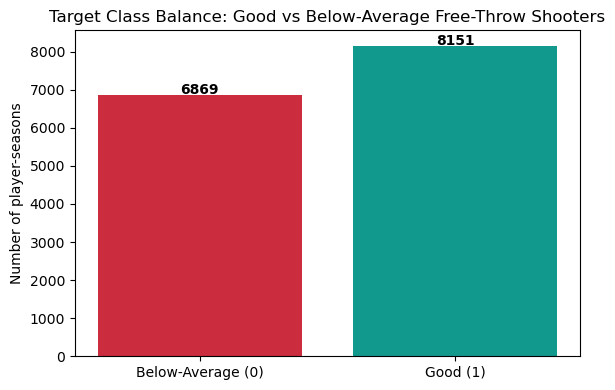

In [79]:
# Plot 1: Below-Average vs Good class balance
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['target'].value_counts().sort_index()
ax.bar(['Below-Average (0)', 'Good (1)'], counts.values, color=['#cb2d3e', '#11998e'])
ax.set_title('Target Class Balance: Good vs Below-Average Free-Throw Shooters')
ax.set_ylabel('Number of player-seasons')
for i, v in enumerate(counts.values):
    ax.text(i, v + 30, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../images/eda_target_balance.png', dpi=100, bbox_inches='tight')
plt.show()

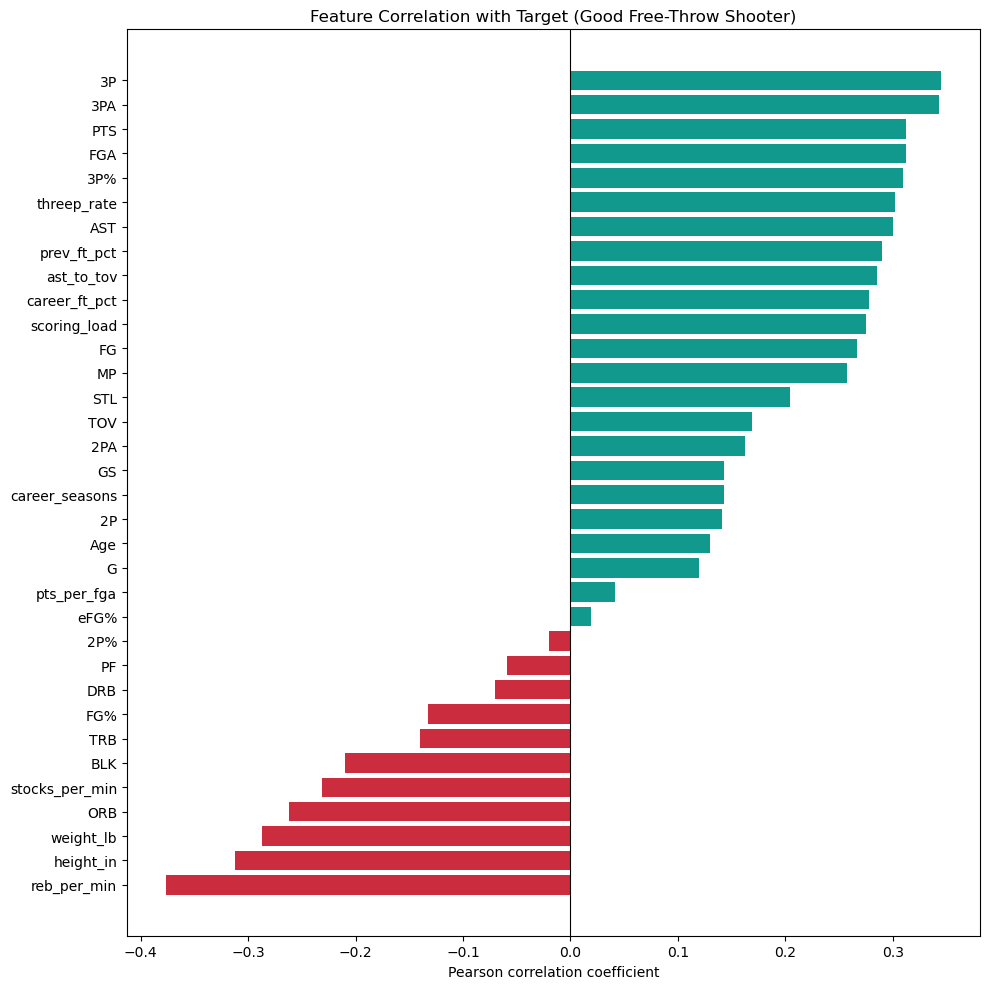

In [80]:
# Plot 2: Feature correlation with target
numeric_features = df.select_dtypes(include='number').columns.tolist()
numeric_features = [c for c in numeric_features if c != 'target']
correlations = df[numeric_features + ['target']].corr()['target'].drop('target').sort_values()

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#cb2d3e' if v < 0 else '#11998e' for v in correlations.values]
ax.barh(correlations.index, correlations.values, color=colors)
ax.set_title('Feature Correlation with Target (Good Free-Throw Shooter)')
ax.set_xlabel('Pearson correlation coefficient')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('../images/eda_feature_correlation.png', dpi=100, bbox_inches='tight')
plt.show()
# Historical FT features (career_ft_pct, prev_ft_pct) are the strongest positive predictors.
# Big-man stats (height, weight, BLK, reb_per_min) correlate negatively.

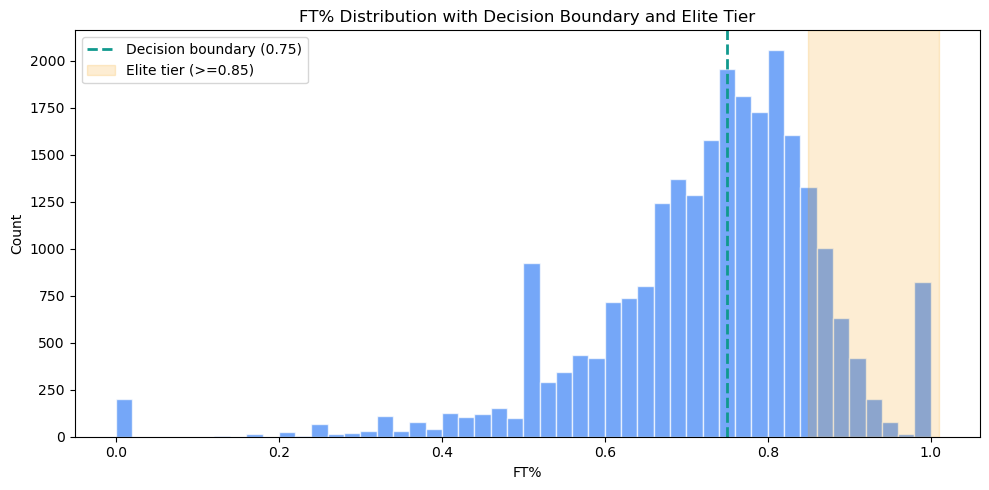

In [81]:
# Plot 3: FT% distribution with 0.75 decision boundary and >=0.85 elite shading
ft_all = df_raw[df_raw['Player'] != 'League Average']['FT%'].dropna()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(ft_all, bins=50, color='#3B82F6', alpha=0.7, edgecolor='white')
ax.axvline(0.75, color='#11998e', linewidth=2, linestyle='--', label='Decision boundary (0.75)')
ax.axvspan(0.85, ft_all.max() + 0.01, alpha=0.18, color='#F59E0B', label='Elite tier (>=0.85)')
ax.set_title('FT% Distribution with Decision Boundary and Elite Tier')
ax.set_xlabel('FT%')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('../images/eda_ft_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
# Players above 0.75 are classified as Good (1); the shaded region shows the
# Elite sub-group (>=0.85), included as analysis only — not a separate model target.

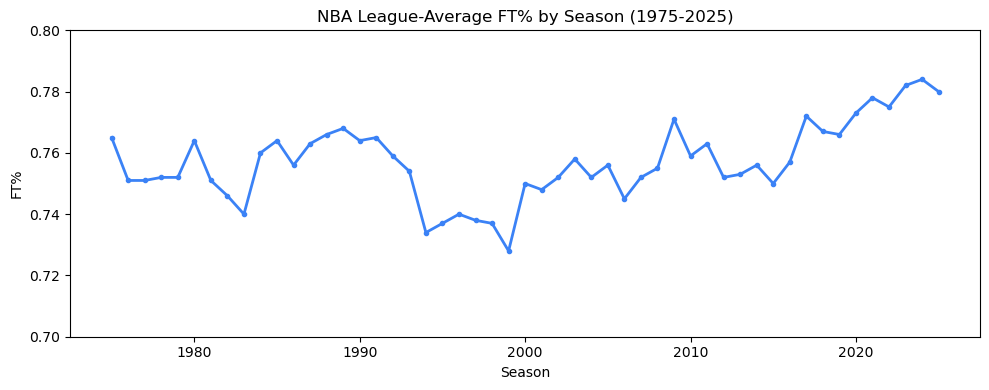

In [82]:
# Plot 4: League-average FT% across seasons
league_hist = league_avg_rows[['Season', 'FT%']].copy()
league_hist = league_hist.dropna().sort_values('Season')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(league_hist['Season'], league_hist['FT%'], color='#3B82F6', linewidth=2, marker='o', markersize=3)
ax.set_title('NBA League-Average FT% by Season (1975-2025)')
ax.set_xlabel('Season')
ax.set_ylabel('FT%')
ax.set_ylim(0.70, 0.80)
plt.tight_layout()
plt.savefig('../images/eda_league_avg_ft.png', dpi=100, bbox_inches='tight')
plt.show()
# League FT% is relatively stable (0.728-0.784) and trends upward slightly in recent years.

## Step 15: Save the final dataset

In [83]:
df.to_csv('../data/cleaned_data.csv', index=False)
print('Saved ../data/cleaned_data.csv - shape:', df.shape)

Saved ../data/cleaned_data.csv - shape: (15020, 40)


## Step 16: Save the feature column list

In [84]:
feature_columns = [c for c in df.columns if c != 'target']
joblib.dump(feature_columns, '../models/feature_columns.pkl')
print(f'Saved {len(feature_columns)} feature columns to ../models/feature_columns.pkl')
print(feature_columns)

Saved 39 feature columns to ../models/feature_columns.pkl
['Age', 'G', 'GS', 'MP', 'FG', 'FGA', 'FG%', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'career_ft_pct', 'prev_ft_pct', 'career_seasons', 'height_in', 'weight_lb', 'ast_to_tov', 'pts_per_fga', 'threep_rate', 'reb_per_min', 'stocks_per_min', 'scoring_load', 'Pos_C', 'Pos_PF', 'Pos_PG', 'Pos_SF', 'Pos_SG']
